Always run this block first !

In [ ]:
import time
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import os
import re

In [ ]:
import tempfile

def atomic_pickle_dump(obj, final_path, verbose=True):
    dir_name = os.path.dirname(final_path)

    if verbose:
        print(f"[atomic_pickle_dump] Saving to temporary file in: {dir_name}")

    with tempfile.NamedTemporaryFile(
        dir=dir_name, delete=False, suffix=".tmp"
    ) as tmp:
        pickle.dump(obj, tmp)
        tmp.flush()
        os.fsync(tmp.fileno())
        tmp_path = tmp.name

        if verbose:
            print(f"[atomic_pickle_dump] ✓ Written and flushed temp file: {tmp_path}")

    os.replace(tmp_path, final_path)

    if verbose:
        print(f"[atomic_pickle_dump] ✅ Successfully promoted temp file → {final_path}")

# 1. CVXPY Solver Linear (No need to run if results exist)
Result savepath: /content/drive/MyDrive/experiment_result/

## Setup Functions

In [ ]:
# --- Hàm xây dựng Ma trận A (từ Ảnh 2) ---
def build_A_matrix(n_goods, n_slots):
    """Tạo ma trận ánh xạ Goods -> Slots"""
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

In [ ]:
# --- CENTRAL SOLVER ---
def solve_centralized(supply_s, capacity_b, valuations, budgets, A):
  """
  Solves the primal E-G program with personalized constraints
  and prints iteration logs.
  """
  n_buyers, m_goods = valuations.shape
  obj_hist = []

  # Shared variable
  X = cp.Variable((n_buyers, m_goods), nonneg=True)

  # Constraints
  constraints = [cp.sum(X, axis=0) <= supply_s]
  for i in range(n_buyers):
      constraints.append(A @ X[i] <= capacity_b[i])

  # Objective
  obj_terms = []
  utilities = cp.sum(cp.multiply(valuations, X), axis=1)
  primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

  objective = cp.Maximize(primal_utility)

  # Initial objective (lúc này chưa ai mua gì)
  p = np.ones(m_goods)
  q = np.ones((n_buyers, m_goods // 6))
  util = [valuations[j] @ np.ones(m_goods) for j in range(n_buyers)]
  term_p = np.sum(p * supply_s)     # p * Supply
  term_q = np.sum(q * capacity_b)            # q * Capacity
  term_u = np.sum(budgets * np.log(util) + 1e-12) # Utility
  obj_0 = term_p + term_q + term_u - np.sum(budgets)
  obj_hist.append(obj_0)

  # Solve problem
  prob = cp.Problem(objective, constraints)

  try:
      prob.solve(solver=cp.SCS, verbose=False)
  except cp.error.SolverError:
      print("SCS failed or not installed.")

  obj_hist.append(prob.value)
  stats = prob.solver_stats
  print(f"\nIterations: {stats.num_iters}")
  if prob.status not in ['optimal', 'optimal_inaccurate']:
      print(f"\nCentralized solver failed/infeasible. Status: {prob.status}")
      return None

  return X.value, obj_hist, stats.num_iters

## 10 users 24 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(10, 24) + 0.1
valuations /= 10

# --- CONFIGURATION ---
n_buyers, n_goods = valuations.shape
n_slots = 4
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (10, 24)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_10u_24i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (4, 24)

Optimal solutions from solver...
Experiment begins
Iterations: 2925

Solver finished in 0.13 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_10u_24i.pkl


## 50 users and 60 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_50u_60i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(50, 60) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
n_slots = 10
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (50, 60)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_50u_60i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")


Đã tạo Ma trận A với shape: (10, 60)

Optimal solutions from solver...
Experiment begins
Iterations: 4125

Solver finished in 0.96 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_50u_60i.pkl


In [ ]:
print(solver_obj)

[np.float64(1201.5700388666667), np.float64(-960.1565920030549)]


## 100 users and 150 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_100u_150i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(100, 150) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
n_slots = 25
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (100, 150)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_100u_150i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")


Đã tạo Ma trận A với shape: (25, 150)

Optimal solutions from solver...
Experiment begins
Iterations: 6725

Solver finished in 8.76 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_100u_150i.pkl


## 150 users and 180 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_150u_180i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(150, 180) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 30
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (150, 180)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_150u_180i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (30, 180)

Optimal solutions from solver...
Experiment begins
Iterations: 7900

Solver finished in 18.10 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_150u_180i.pkl


In [ ]:
print(solver_obj)

[np.float64(11068.415729340839), np.float64(-4498.1936168563825)]


## 200 users and 240 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_200u_240i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(200, 240) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 40
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (200, 240)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_200u_240i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (40, 240)

Optimal solutions from solver...
Experiment begins
Iterations: 8925

Solver finished in 44.22 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_200u_240i.pkl


## 300 users and 360 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_300u_360i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(300, 360) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 60
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (300, 360)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_300u_360i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (60, 360)

Optimal solutions from solver...
Experiment begins
Iterations: 19525

Solver finished in 249.01 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_300u_360i.pkl


## 400 users and 480 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_400u_480i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(400, 480) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 80
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (400, 480)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_400u_480i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (80, 480)

Optimal solutions from solver...
Experiment begins
Iterations: 24750

Solver finished in 609.27 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_400u_480i.pkl


## 500 users and 600 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_500u_600i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(500, 600) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 100
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

✓ Valuations Shape: (500, 600)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_500u_600i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (100, 600)

Optimal solutions from solver...
Experiment begins
Iterations: 36900

Solver finished in 1530.46 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_500u_600i.pkl


## 600 users and 720 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_600u_720i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(600, 720) + 0.1
valuations /= 10

n_buyers, n_goods = valuations.shape
n_slots = 120
np.random.seed(1)
p0      = np.ones(n_goods)    # Initial prices
q0      = np.ones(n_buyers)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)


In [ ]:
t0_solver = time.perf_counter()

# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

print("\nOptimal solutions from solver...")
print(f"Experiment begins", end="\r")

# --- FINAL ALLOCATION & TIME ---
solver_alloc, solver_obj, solver_iters = solve_centralized(supply_s, capacity_b, valuations, budgets, A_matrix)
t_solver = time.perf_counter() - t0_solver
print(f"\nSolver finished in {t_solver:.2f} s")

# --- SAVE RESULT
data_to_save = {
    "t_solver": t_solver,
    "solver_alloc": solver_alloc,
    "objective": solver_obj,
    "iterations": solver_iters,
    "config": {
        "n_buyers": n_buyers,
        "n_goods": n_goods,
        "p0": p0,
        "q0": q0,
        "budgets": budgets,
        "supply_s": supply_s,
        "capacity_b": capacity_b,
        "n_slots": n_slots
    }
}

# Save to pickle file
filename = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_600u_720i.pkl"
with open(filename, "wb") as f:
    pickle.dump(data_to_save, f)

print(f"✅ Data saved successfully to {filename}")

Đã tạo Ma trận A với shape: (120, 720)

Optimal solutions from solver...
Experiment begins
Iterations: 5150

Solver finished in 290.93 s
✅ Data saved successfully to /content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_600u_720i.pkl


# 2. SPDS Algorithm with Constraint (No need to run if results exist)
Result savepath: /content/drive/MyDrive/experiment_result/

In [ ]:
# --- Hàm xây dựng Ma trận A (từ Ảnh 2) ---
def build_A_matrix(n_goods, n_slots):
    """Tạo ma trận ánh xạ Goods -> Slots"""
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

# --- Hàm buyer best response for each user used in SPDS
def buyer_best_response_cvx(v_i, p, A, q_i, B_i, utility_type="Linear"):
    """
    Phiên bản siêu tốc của buyer_best_response.
    Sử dụng Closed-form solution cho mọi hàm utility.
    KHÔNG DÙNG CVXPY.
    """
    # 1. Tính giá hiệu dụng (Effective Price)
    # p: (M,), A.T @ q_i: (M,)
    effective_price = p + (A.T @ q_i)

    # An toàn: Đảm bảo giá > 0 để tránh chia cho 0
    safe_price = np.maximum(effective_price, 1e-9)

    m_goods = len(v_i)
    x = np.zeros(m_goods)

    # =========================================================
    # 1. LINEAR UTILITY: U = sum(v * x)
    # =========================================================
    if utility_type == "Linear":
        # Chiến thuật: Bang-per-buck (Mua tất tay món hời nhất)
        bang_per_buck = v_i / safe_price
        best_idx = np.argmax(bang_per_buck)
        x[best_idx] = B_i / safe_price[best_idx]

    # =========================================================
    # 2. COBB-DOUGLAS: U = prod(x^alpha) hoặc sum(alpha * log(x))
    # =========================================================
    elif utility_type == "Cobb-Douglas":
        # Chuẩn hóa alpha (Bắt buộc để thỏa mãn Budget constraint)
        sum_v = np.sum(v_i)
        if sum_v > 0:
            alpha = v_i / sum_v
        else:
            alpha = np.zeros_like(v_i) # Tránh lỗi nếu v toàn 0

        # Công thức: Chi tiêu đúng tỷ lệ alpha
        # x_i = (alpha_i * Budget) / Price_i
        x = (alpha * B_i) / safe_price

    # =========================================================
    # 3. LEONTIEF: U = min(x / v)
    # =========================================================
    elif utility_type == "Leontief":
        # Chiến thuật: Mua theo tỷ lệ cố định của v
        # Giá của 1 combo chuẩn = sum(v_i * p_i)
        cost_of_one_bundle = np.dot(v_i, safe_price)

        if cost_of_one_bundle > 0:
            # Số lượng combo mua được
            num_bundles = B_i / cost_of_one_bundle
            x = num_bundles * v_i
        else:
            x = np.zeros(m_goods)

    # =========================================================
    # 4. CES UTILITY: U = (sum v * x^rho)^(1/rho)
    # =========================================================
    elif utility_type == "CES_8":
        # CẤU HÌNH rho (m) TẠI ĐÂY
        # Trong code cũ bạn để m = 1/2
        rho = 0.5

        # --- CASE A: CONCAVE (rho < 1, rho != 0) ---
        # Đây là trường hợp thay thế (Substitute) -> Mua nhiều loại
        if rho < 1:
            # Tính Sigma (Elasticity of Substitution)
            # sigma = 1 / (1 - rho)
            sigma = 1.0 / (1.0 - rho)

            # Tính phần tử tỷ lệ: Term_i = (v_i / p_i)^sigma
            # Dùng np.maximum cho v_i để tránh v=0 gây lỗi log hoặc mũ âm
            term = np.power(v_i / safe_price, sigma)

            # Tính mẫu số chung: Sum (p_j * term_j)
            denom = np.dot(safe_price, term)

            if denom > 0:
                # x_i = (B * term_i) / denom
                x = (B_i * term) / denom
            else:
                 # Fallback nếu v=0 hết
                 x = np.zeros(m_goods)

        # --- CASE B: CONVEX (rho > 1) ---
        # Đây là trường hợp "Winner Takes All" giống Linear
        else:
            # So sánh tỷ lệ: v^(1/rho) / p
            v_transformed = np.power(v_i, 1.0/rho)
            bang_per_buck = v_transformed / safe_price

            best_idx = np.argmax(bang_per_buck)
            x[best_idx] = B_i / safe_price[best_idx]

    return x

# --- GROUND TRUTH OPTIMAL RESULT
def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A, utility_type="Linear"):
    """
    Returns:
        optimal_value (float): Giá trị hàm mục tiêu tối ưu.
        optimal_X (np.ndarray): Ma trận phân bổ tối ưu (N x M).
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    constraints = [
        cp.sum(X, axis=0) <= supply_s
    ]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    # --- XÂY DỰNG OBJECTIVE ---
    if utility_type == "Linear":
        utilities = cp.sum(cp.multiply(valuations, X), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "Cobb-Douglas":
        eps = 1e-12
        alpha = valuations / (np.sum(valuations, axis=1, keepdims=True))
        log_utilities = cp.sum(cp.multiply(alpha, cp.log(X + eps)), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    elif utility_type == "Leontief":
        # Lưu ý: Leontief trong CVXPY có thể phức tạp/chậm với quy mô lớn
        inv_valuations = np.divide(
            1.0,
            valuations,
            out=np.full_like(valuations, 1e30),
            where=(valuations > 0)
        )

        # 2. Nhân X với ma trận nghịch đảo hằng số này
        # ratio_matrix[i, j] = X[i, j] * (1 / v[i, j])
        weighted_X = cp.multiply(X, inv_valuations)

        # 3. Lấy min theo hàng
        utilities = cp.min(weighted_X, axis=1)

        # 4. Tính hàm mục tiêu
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "CES_8":
        # Nếu chạy Solver tập trung, m NÊN nhỏ hơn hoặc bằng 1 (ví dụ 0.5 hoặc -1).
        # Nếu đặt m = 8, Solver ECOS/SCS sẽ KHÔNG giải được (báo lỗi DCPError).
        eps = 1e-9
        m_ces = 1/2

        # Công thức: log_util = (1/m) * log( sum( v * x^m ) )
        # Tính tổng trọng số lũy thừa theo hàng (axis=1)
        inner_term = cp.sum(cp.multiply(valuations, cp.power(X + eps, m_ces)), axis=1)

        # Logarit hóa hàm mục tiêu
        log_utilities = (1.0 / m_ces) * cp.log(inner_term)

        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    objective = cp.Maximize(primal_utility)
    prob = cp.Problem(objective, constraints)

    print(f"--- Solving Centralized Fair Problem ({utility_type}) ---")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    # TRẢ VỀ: (Giá trị mục tiêu, Ma trận X tối ưu)
    return prob.value, X.value

In [ ]:
""" UTILITY FUNCTIONS """
# --- CES / Linear (m = CES exponent, m=1 → Linear, m='inf' → Leontief-like max) ---
def calculate_ces_utility(allocation_vec, valuation_vec, m_ces = 1/2):
    eps = 1e-9
    return np.power(np.power(allocation_vec + eps, m_ces).T @ valuation_vec, (1/m_ces))

# --- COBB–DOUGLAS UTILITY ---
def calculate_cd_utility(allocation_vec, valuations_vec):
    eps = 1e-12
    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)

    # Normalize weights α_j = v_j / sum(v)
    weights = v / (np.sum(v, axis=1, keepdims=True))

    # log utility = Σ α_j log(x_j)
    log_u = np.sum(weights * np.log(x + eps), axis=1)

    u = np.exp(log_u)

    return u

# --- LEONTIEF UTILITY ---
def calculate_leo_utility(allocation_vec, valuations_vec):
    v = np.atleast_2d(valuations_vec)
    x = np.atleast_2d(allocation_vec)
    # 1. Khởi tạo mảng kết quả là Vô cực (Infinity)
    # Để nếu v=0, giá trị tại đó vẫn là Inf và không bị hàm min chọn phải
    ratios = np.full_like(x, 1e30)

    # 2. Chỉ thực hiện phép chia ở những nơi v > 0
    # Ghi đè kết quả phép chia vào mảng ratios
    np.divide(x, v, out=ratios, where=(v > 1e-12))

    # 3. Lấy Min theo hàng (axis=1)
    u = np.min(ratios, axis=1)

    return u

In [ ]:
np.seterr(all='ignore') # Ignore warnings log(0)
# --- MAIN ALGORITHM ---
def one_sample_sgd_fastlog(
    A: np.ndarray, b: np.ndarray, supply_s: np.ndarray, q0: np.ndarray,
    valuations: np.ndarray, budgets: np.ndarray, p0: np.ndarray,
    lr_p=0.01, lr_q=0.01, num_iters=1000000, seed=42, log_freq=5000,
    utility_type="Linear", eps=0.00001):
    """
    Phiên bản SGD cho mô hình Ma trận A (vector q_i).
    """
    # Marks starting time of setup
    t0 = time.perf_counter()

    #--- Khởi tạo ---
    rng = np.random.default_rng(seed)
    n, m = valuations.shape
    # Copy biến dual
    p = p0.copy()
    q = q0.copy()

     # --- BƯỚC 1: KHỞI TẠO TUYỆT ĐỐI (X0 = 100) ---
    X = np.ones((n, m)) * 1
    util =  np.zeros(n)
    for j in range(n):
        if utility_type == "Linear":
            util[j] = valuations[j] @ X[j]
        elif utility_type == "Cobb-Douglas":
            util[j] = calculate_cd_utility(X[j], valuations[j])
        elif utility_type == "Leontief":
            util[j] = calculate_leo_utility(X[j], valuations[j])
        elif utility_type == "CES_8":
            util[j] = calculate_ces_utility(X[j], valuations[j], m_ces=0.5)

    # --- 2. GHI LOG TRẠNG THÁI BAN ĐẦU (t=0) ---
    # Khởi tạo lịch sử
    num_logs = num_iters // 10 + 1
    obj_hist = np.empty(num_iters)
    time_hist = np.empty(num_iters)
    log_idx = 0

    # Tính Objective tại điểm xuất phát (lúc này chưa ai mua gì)
    term_p = np.sum(p * supply_s)     # p * Supply
    term_q = np.sum(q * b)            # q * Capacity
    term_u = np.sum(budgets * np.log(util + 1e-12)) # Utility
    obj_0 = term_p + term_q + term_u - np.sum(budgets)

    obj_hist[log_idx] = obj_0
    time_hist[log_idx] = 0.0
    log_idx += 1

    print(f"--- Start SGD ({num_iters} iterations) | Initial Obj: {obj_0:.2f} ---")

    # --- WARM UP ---
    for j in range(n):
        # Dùng hàm Analytical siêu tốc
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j], utility_type)

        # Cập nhật util để dùng cho vòng lặp sau
        if utility_type == "Linear":
            util[j] = valuations[j] @ X[j]
        elif utility_type == "Cobb-Douglas":
            util[j] = calculate_cd_utility(X[j], valuations[j])
        elif utility_type == "Leontief":
            util[j] = calculate_leo_utility(X[j], valuations[j])
        elif utility_type == "CES_8":
            util[j] = calculate_ces_utility(X[j], valuations[j], m_ces=0.5)

    # Tính Tổng cầu ban đầu (D) sau khi Warm up
    D = X.sum(axis=0)

    # Variables to track times for modeling parallel execution
    total_br_computation_time = 0.0 # Sum of all individual buyer_best_response_cvx times
    total_non_br_computation_time = 0.0 # Sum of all other sequential operations (gradients, dual updates)


    # Mark start of SGD loop for time measurement
    t_sgd_loop_start = time.perf_counter()

    # --- Vòng lặp SGD ---
    try:
        for t in range(1, num_iters + 1):
            # 1. Chọn buyer ngẫu nhiên
            i = int(rng.integers(n))

            # Track time for buyer_best_response_cvx (parallelizable part)
            t_br_start = time.perf_counter()
            # 2. Cập nhật D và X[i]
            D -= X[i]
            # Gọi hàm best_response MỚI (với q[i] là vector)
            x_new = buyer_best_response_cvx(valuations[i], p, A, q[i], budgets[i], utility_type)

            t_br_end = time.perf_counter()
            delta_t_br = t_br_end - t_br_start
            total_br_computation_time += delta_t_br

            X[i] = x_new
            if utility_type == "Linear":
                util[i] = valuations[i] @ X[i]
            elif utility_type == "Cobb-Douglas":
                util[i] = calculate_cd_utility(valuations[i], X[i])
            elif utility_type == "Leontief":
                util[j] = calculate_leo_utility(valuations[i], X[i])

            D += x_new

            # Track time for other sequential operations
            t_non_br_start = time.perf_counter()

            # 3. TÍNH GRADIENT
            # Gradient của p: (Tổng Cầu - Tổng Cung)
            # Nếu D > S -> g_p > 0 -> p cần tăng
            g_p = D - supply_s

            # Gradient của q_i: (Tải trọng cá nhân - Capacity cá nhân)
            # Load tại slot = A * x
            load_i = A @ x_new
            g_q_i = load_i - b[i]

            # E. CẬP NHẬT BIẾN DUAL (Gradient Ascent cho bài toán Dual)
            # Decay Learning Rate: 1 / sqrt(t)
            alpha = lr_p / np.sqrt(t)
            beta  = lr_q / np.sqrt(t)

            p = np.maximum(0, p + alpha * g_p)
            q[i] = np.maximum(0, q[i] + beta * g_q_i)

            delta_t_non_br = time.perf_counter() - t_non_br_start
            total_non_br_computation_time += delta_t_non_br

            # 6. Log định kỳ
            if t % log_freq == 0:
                # Tính Objective Value
                term_p = np.sum(p * supply_s) # Sử dụng supply_s truyền vào
                term_q = np.sum(q * b)
                term_u = np.sum(budgets * np.log(util + 1e-12))
                obj = term_p + term_q + term_u - np.sum(budgets)

                # Modelled parallel time: sum of all BR times divided by n (ideal speedup)
                # Add other non-BR times (gradients, dual updates) as sequential.
                effective_parallel_time_point = (total_br_computation_time / n) + total_non_br_computation_time

                # Update history
                obj_hist[log_idx] = obj
                time_hist[log_idx] = effective_parallel_time_point
                # Update log_idx in numpy array
                log_idx += 1
                # --- Termination conditions ---
                ratio = abs((obj_hist[log_idx - 1] - obj_hist[log_idx - 2]) / obj_hist[log_idx - 2])
                if ratio <= eps:
                    print(f"SPDS Iterations: {t}")
                    print(f"Objective value: {obj:.4f}")
                    print(f"SPDS Algorithm finsished at epsilon difference {eps} in {effective_parallel_time_point:.2f} s")
                    break
                elif ratio <= 0.0001:
                    log_freq = n * 10 / 4
                elif ratio <= 0.001:
                    log_freq = n * 10 / 2

    except KeyboardInterrupt:
        print("🛑 Interrupted by user")

    except Exception as e:
        print(f"💥 Crash: {e}")

    return obj_hist[:log_idx], time_hist[:log_idx], X.copy(), p.copy(), q.copy()

## 100 users and 150 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_100u_150i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(100, 150) + 0.1
valuations /= 10

# --- PARAMETERS ---
n_buyers, n_goods = valuations.shape
n_slots = 25
p0 = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (100, 150)

Thiết lập hoàn tất. (n_buyers=100, n_goods=150)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix,
        'Description': "100 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_100u_150i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (25, 150)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -2593.4031
★ Optimal Allocation Shape (X*): (100, 150)
--- Start SGD (10000000 iterations) | Initial Obj: 110.76 ---
SPDS Iterations: 22000
Objective value: -2588.6114
SPDS Algorithm finsished at epsilon difference 1e-05 in 0.90 s

SGD finished in 2.11 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmpzeyh97ff.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_100u_150i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_100u_150i.pkl


## 200 users and 240 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_200u_240i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(200, 240) + 0.1
valuations /= 10

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
n_slots = 40
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (200, 240)

Thiết lập hoàn tất. (n_buyers=200, n_goods=240)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix,
        'Description': "200 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (40, 240)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -6555.3234
★ Optimal Allocation Shape (X*): (200, 240)
--- Start SGD (10000000 iterations) | Initial Obj: -204.52 ---
SPDS Iterations: 23000
Objective value: -6462.2518
SPDS Algorithm finsished at epsilon difference 1e-05 in 0.43 s

SGD finished in 1.05 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmp649k10za.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl


## 300 users and 360 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_300u_360i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(300, 360) + 0.1
valuations /= 10

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
n_slots = 60
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (300, 360)

Thiết lập hoàn tất. (n_buyers=300, n_goods=360)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new  = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix,
        'Description': "300 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_300u_360i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (60, 360)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -11024.8890
★ Optimal Allocation Shape (X*): (300, 360)
--- Start SGD (10000000 iterations) | Initial Obj: -278.60 ---
SPDS Iterations: 36000
Objective value: -10804.5727
SPDS Algorithm finsished at epsilon difference 1e-05 in 1.12 s

SGD finished in 2.63 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmp_blwi1xh.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_300u_360i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_300u_360i.pkl


## 400 users and 480 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_400u_480i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(400, 480) + 0.1
valuations /= 10

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
n_slots = 80
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (400, 480)

Thiết lập hoàn tất. (n_buyers=400, n_goods=480)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p_new'      : p_new,
        'q_new'      : q_new,
        'A_matrix': A_matrix,
        'Description': "300 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_400u_480i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (80, 480)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -15871.5403
★ Optimal Allocation Shape (X*): (400, 480)
--- Start SGD (10000000 iterations) | Initial Obj: -384.52 ---
SPDS Iterations: 48000
Objective value: -15302.0717
SPDS Algorithm finsished at epsilon difference 1e-05 in 1.76 s

SGD finished in 4.13 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmp6fmwc0n5.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_400u_480i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_400u_480i.pkl


## 500 users and 600 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_500u_600i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(500, 600) + 0.1
valuations /= 10

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
n_slots = 100
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (500, 600)

Thiết lập hoàn tất. (n_buyers=500, n_goods=600)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p_new'      : p_new,
        'q_new'      : q_new,
        'A_matrix': A_matrix,
        'Description': "300 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_500u_600i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (100, 600)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -20971.4591
★ Optimal Allocation Shape (X*): (500, 600)
--- Start SGD (10000000 iterations) | Initial Obj: -491.74 ---
SPDS Iterations: 65000
Objective value: -20421.7793
SPDS Algorithm finsished at epsilon difference 1e-05 in 2.33 s

SGD finished in 5.72 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmpyt87v50u.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_500u_600i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_500u_600i.pkl


## 600 users and 720 items

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_600u_720i"

# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(600, 720) + 0.1
valuations /= 10

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
n_slots = 120
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

# Same parameters
num_iters = 10000000
log_freq  = 10 * n_buyers
current_lr = 0.0005
print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)

Thiết lập hoàn tất. (n_buyers=600, n_goods=720)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
            valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN SPDS ---
t0 = time.perf_counter()
obj_sgd, sgd_runtime, sgd_allocation, p_new, q_new = one_sample_sgd_fastlog(
        A_matrix, capacity_b, supply_s, q0, valuations, budgets, p0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)

t_sgd = time.perf_counter() - t0
print(f"\nSGD finished in {t_sgd:.2f} s")

# --- SAVE RESULT ---
all_results = {
    'objective': obj_sgd,
    'time_log': sgd_runtime,
    'alloc_final': sgd_allocation,
    'total_time': t_sgd,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'num_iters' : len(obj_sgd) * log_freq,
        'log_freq' : log_freq
    },
    'data': {
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'n_slots' : n_slots,
        'budgets' : budgets,
        'capacity_b': capacity_b,
        'supply_s': supply_s,
        'p_new'      : p_new,
        'q_new'      : q_new,
        'A_matrix': A_matrix,
        'Description': "300 users data with constrained"
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_600u_720i.pkl'
atomic_pickle_dump(all_results, save_path_pickle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (120, 720)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -79.7667
★ Optimal Allocation Shape (X*): (600, 720)
--- Start SGD (10000000 iterations) | Initial Obj: 21996.63 ---
SPDS Iterations: 1953000
Objective value: -70.6667
SPDS Algorithm finsished at epsilon difference 1e-05 in 83.97 s

SGD finished in 195.04 s
[atomic_pickle_dump] Saving to temporary file in: /content/drive/MyDrive/EV_charging_project/experiment_result
[atomic_pickle_dump] ✓ Written and flushed temp file: /content/drive/MyDrive/EV_charging_project/experiment_result/tmpldhhj1fz.tmp
[atomic_pickle_dump] ✅ Successfully promoted temp file → /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_600u_720i.pkl
Đã lưu thành công TOÀN BỘ kết quả vào: /content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_600u_720i.pkl


# 3. DPDS Algorithm

In [ ]:
# --- Hàm xây dựng Ma trận A (từ Ảnh 2) ---
def build_A_matrix(n_goods, n_slots):
    """Tạo ma trận ánh xạ Goods -> Slots"""
    A = np.zeros((n_slots, n_goods))
    for j in range(n_goods):
        A[j % n_slots, j] = 1.0
    return A

In [ ]:
# --- Hàm buyer best response for each user used in SPDS
def buyer_best_response_cvx(v_i, p, A, q_i, B_i, utility_type="Linear"):
    """
    Phiên bản siêu tốc của buyer_best_response.
    Sử dụng Closed-form solution cho mọi hàm utility.
    KHÔNG DÙNG CVXPY.
    """
    # 1. Tính giá hiệu dụng (Effective Price)
    # p: (M,), A.T @ q_i: (M,)
    effective_price = p + (A.T @ q_i)

    # An toàn: Đảm bảo giá > 0 để tránh chia cho 0
    safe_price = np.maximum(effective_price, 1e-9)

    m_goods = len(v_i)
    x = np.zeros(m_goods)

    # =========================================================
    # 1. LINEAR UTILITY: U = sum(v * x)
    # =========================================================
    if utility_type == "Linear":
        # Chiến thuật: Bang-per-buck (Mua tất tay món hời nhất)
        bang_per_buck = v_i / safe_price
        best_idx = np.argmax(bang_per_buck)
        x[best_idx] = B_i / safe_price[best_idx]

    # =========================================================
    # 2. COBB-DOUGLAS: U = prod(x^alpha) hoặc sum(alpha * log(x))
    # =========================================================
    elif utility_type == "Cobb-Douglas":
        # Chuẩn hóa alpha (Bắt buộc để thỏa mãn Budget constraint)
        sum_v = np.sum(v_i)
        if sum_v > 0:
            alpha = v_i / sum_v
        else:
            alpha = np.zeros_like(v_i) # Tránh lỗi nếu v toàn 0

        # Công thức: Chi tiêu đúng tỷ lệ alpha
        # x_i = (alpha_i * Budget) / Price_i
        x = (alpha * B_i) / safe_price

    # =========================================================
    # 3. LEONTIEF: U = min(x / v)
    # =========================================================
    elif utility_type == "Leontief":
        # Chiến thuật: Mua theo tỷ lệ cố định của v
        # Giá của 1 combo chuẩn = sum(v_i * p_i)
        cost_of_one_bundle = np.dot(v_i, safe_price)

        if cost_of_one_bundle > 0:
            # Số lượng combo mua được
            num_bundles = B_i / cost_of_one_bundle
            x = num_bundles * v_i
        else:
            x = np.zeros(m_goods)

    # =========================================================
    # 4. CES UTILITY: U = (sum v * x^rho)^(1/rho)
    # =========================================================
    elif utility_type == "CES_8":
        # CẤU HÌNH rho (m) TẠI ĐÂY
        # Trong code cũ bạn để m = 1/2
        rho = 0.5

        # --- CASE A: CONCAVE (rho < 1, rho != 0) ---
        # Đây là trường hợp thay thế (Substitute) -> Mua nhiều loại
        if rho < 1:
            # Tính Sigma (Elasticity of Substitution)
            # sigma = 1 / (1 - rho)
            sigma = 1.0 / (1.0 - rho)

            # Tính phần tử tỷ lệ: Term_i = (v_i / p_i)^sigma
            # Dùng np.maximum cho v_i để tránh v=0 gây lỗi log hoặc mũ âm
            term = np.power(v_i / safe_price, sigma)

            # Tính mẫu số chung: Sum (p_j * term_j)
            denom = np.dot(safe_price, term)

            if denom > 0:
                # x_i = (B * term_i) / denom
                x = (B_i * term) / denom
            else:
                 # Fallback nếu v=0 hết
                 x = np.zeros(m_goods)

        # --- CASE B: CONVEX (rho > 1) ---
        # Đây là trường hợp "Winner Takes All" giống Linear
        else:
            # So sánh tỷ lệ: v^(1/rho) / p
            v_transformed = np.power(v_i, 1.0/rho)
            bang_per_buck = v_transformed / safe_price

            best_idx = np.argmax(bang_per_buck)
            x[best_idx] = B_i / safe_price[best_idx]

    return x

# --- GROUND TRUTH OPTIMAL RESULT
def solve_centralized_optimal_fair(valuations, budgets, supply_s, b_mat, A, utility_type="Linear"):
    """
    Returns:
        optimal_value (float): Giá trị hàm mục tiêu tối ưu.
        optimal_X (np.ndarray): Ma trận phân bổ tối ưu (N x M).
    """
    n, m = valuations.shape
    X = cp.Variable((n, m), nonneg=True)

    constraints = [
        cp.sum(X, axis=0) <= supply_s
    ]
    for i in range(n):
        constraints.append(A @ X[i] <= b_mat[i])

    # --- XÂY DỰNG OBJECTIVE ---
    if utility_type == "Linear":
        utilities = cp.sum(cp.multiply(valuations, X), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "Cobb-Douglas":
        eps = 1e-12
        alpha = valuations / (np.sum(valuations, axis=1, keepdims=True))
        log_utilities = cp.sum(cp.multiply(alpha, cp.log(X + eps)), axis=1)
        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    elif utility_type == "Leontief":
        # Lưu ý: Leontief trong CVXPY có thể phức tạp/chậm với quy mô lớn
        inv_valuations = np.divide(
            1.0,
            valuations,
            out=np.full_like(valuations, 1e30),
            where=(valuations > 0)
        )

        # 2. Nhân X với ma trận nghịch đảo hằng số này
        # ratio_matrix[i, j] = X[i, j] * (1 / v[i, j])
        weighted_X = cp.multiply(X, inv_valuations)

        # 3. Lấy min theo hàng
        utilities = cp.min(weighted_X, axis=1)

        # 4. Tính hàm mục tiêu
        primal_utility = cp.sum(cp.multiply(budgets, cp.log(utilities + 1e-12)))

    elif utility_type == "CES_8":
        # Nếu chạy Solver tập trung, m NÊN nhỏ hơn hoặc bằng 1 (ví dụ 0.5 hoặc -1).
        # Nếu đặt m = 8, Solver ECOS/SCS sẽ KHÔNG giải được (báo lỗi DCPError).
        eps = 1e-9
        m_ces = 1/2

        # Công thức: log_util = (1/m) * log( sum( v * x^m ) )
        # Tính tổng trọng số lũy thừa theo hàng (axis=1)
        inner_term = cp.sum(cp.multiply(valuations, cp.power(X + eps, m_ces)), axis=1)

        # Logarit hóa hàm mục tiêu
        log_utilities = (1.0 / m_ces) * cp.log(inner_term)

        primal_utility = cp.sum(cp.multiply(budgets, log_utilities))

    objective = cp.Maximize(primal_utility)
    prob = cp.Problem(objective, constraints)

    print(f"--- Solving Centralized Fair Problem ({utility_type}) ---")
    try:
        prob.solve(solver=cp.ECOS, verbose=False)
    except:
        prob.solve(solver=cp.SCS, verbose=False)

    # TRẢ VỀ: (Giá trị mục tiêu, Ma trận X tối ưu)
    return prob.value, X.value

In [ ]:
def full_grad_descent(
    supply_s, capacity_b, A, valuations, budgets,
    p0, q0, lr_p=0.02, lr_q=0.02, num_iters=1000000,
    log_freq=250, seed=42, eps=0.00001):
    """
    Full primal-dual gradient descent with capacity constraints
    """

    np.random.seed(seed)

    n, m = valuations.shape

    p = p0.astype(float).copy()          # goods prices (m,)
    q = q0.astype(float).copy()          # capacity prices (n,T)

    # --- BƯỚC 1: KHỞI TẠO TUYỆT ĐỐI (X0 = 100) ---
    X = np.ones((n, m)) * 1
    util =  np.zeros(n)
    for j in range(n):
        util[j] = valuations[j] @ X[j]

    # --- 2. GHI LOG TRẠNG THÁI BAN ĐẦU (t=0) ---
    # Khởi tạo lịch sử
    num_logs = num_iters // log_freq + 1
    obj_hist = np.empty(num_logs)
    time_hist = np.empty(num_logs)
    log_idx = 0

    # Tính Objective tại điểm xuất phát (lúc này chưa ai mua gì)
    term_p = np.sum(p * supply_s)     # p * Supply
    term_q = np.sum(q * capacity_b)            # q * Capacity
    term_u = np.sum(budgets * np.log(util + 1e-12)) # Utility
    obj_0 = term_p + term_q + term_u - np.sum(budgets)

    obj_hist[log_idx] = obj_0
    time_hist[log_idx] = 0.0
    log_idx += 1

    print(f"--- Start GD ({num_iters} iterations) | Initial Obj: {obj_0:.2f} ---")

    # Easier for final allocation
    X = np.array([buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j])
                for j in range(n)])


    try:
        for t in range(1, num_iters + 1):
            elapsed = time.perf_counter() - t0

            # ---------------------------
            # Buyer's best response
            # ---------------------------
            X = np.array([buyer_best_response_cvx(valuations[j], p, A, q[j], budgets[j])
                for j in range(n)])
            util = np.sum(valuations * X, axis=1)

            # ---------------------------
            # Dual gradients
            # ---------------------------
            g_p = X.sum(axis=0) - supply_s   # (1, m)
            g_q = (A @ X.T).T - capacity_b  # (n,T)

            # Step sizes
            alpha = lr_p / np.sqrt(t)
            beta  = lr_q / np.sqrt(t)

            # Dual updates
            p = np.maximum(p + alpha * g_p, 0.0)
            q = np.maximum(q + beta  * g_q, 0.0)

            term_u = np.sum(budgets * np.log(util + 1e-12))
            term_p = np.sum(p * supply_s)
            term_q = np.sum(q * capacity_b)
            obj = term_u + term_p + term_q - np.sum(budgets)

            # ---------------------------
            # Logging
            # ---------------------------
            if t % log_freq == 0:
                # Update history
                obj_hist[log_idx] = obj
                time_hist[log_idx] = elapsed

                # Update log_idx in numpy array
                log_idx += 1

                # ---------- Termination conditions ----------
                ratio = abs((obj_hist[log_idx - 1] - obj_hist[log_idx - 2]) / obj_hist[log_idx - 2])
                if ratio <= eps:
                    print(f"DPDS Iterations: {t}")
                    print(f"Objective value: {obj:.4f}")
                    print(f"DPDS Algorithm finsished at epsilon difference {eps} in {elapsed:.2f} s")
                    break

    except KeyboardInterrupt:
        print("🛑 Interrupted by user")

    except Exception as e:
        print(f"💥 Crash: {e}")

    return obj_hist[:log_idx], time_hist[:log_idx], X.copy(), p, q

## 100u_150i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_100u_150i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(100, 150) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 25
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (100, 150)

Thiết lập hoàn tất. (n_buyers=100, n_goods=150)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets, p0, q0,
        num_iters=num_iters, lr_p=current_lr, lr_q=current_lr, log_freq=log_freq)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'num_iters' : num_iters,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_100u_150i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (25, 150)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -2593.4031
★ Optimal Allocation Shape (X*): (100, 150)
--- Start GD (10000000 iterations) | Initial Obj: 6378.49 ---
[FULL] Iter 250/10000000 | Obj: 1062402730972.0808| Time: 0.34
[FULL] Iter 500/10000000 | Obj: 1062402722004.0325| Time: 0.69
[FULL] Iter 750/10000000 | Obj: 1062402715618.8459| Time: 1.03
[FULL] Iter 1000/10000000 | Obj: 1062402710436.8342| Time: 1.36
[FULL] Iter 1250/10000000 | Obj: 1062402705931.0437| Time: 1.72
[FULL] Iter 1500/10000000 | Obj: 1062402701808.4387| Time: 2.05
[FULL] Iter 1750/10000000 | Obj: 1062402698162.9656| Time: 2.39
[FULL] Iter 2000/10000000 | Obj: 1062402694763.9506| Time: 2.74
[FULL] Iter 2250/10000000 | Obj: 1062402691590.2469| Time: 3.08
[FULL] Iter 2500/10000000 | Obj: 1062402688558.3354| Time: 3.42
[FULL] Iter 2750/10000000 | Obj: 1062402685737.4783| Time: 3.77
[FULL] Iter 3000/10000000 | Obj: 1062402682986.4041| Time: 4.11
[F

## 200u_240i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_200u_240i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(200, 240) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 40
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets,
        p0, q0, num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'seed': 42,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_200u_240i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

## 300u_360i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_300u_360i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(300, 360) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 60
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets,
        p0, q0, num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'seed': 42,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_300u_360i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

## 400u_480i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_400u_480i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(400, 480) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 80
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

✓ Valuations Shape: (400, 480)

Thiết lập hoàn tất. (n_buyers=400, n_goods=480)


In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets,
        p0, q0, num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'seed': 42,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p0'      : p0,
        'q0'      : q0,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_400u_480i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

Đã tạo Ma trận A với shape: (80, 480)
--- Solving Centralized Fair Problem (Linear) ---
★ Target Dual Optimal (V*): -15871.5403
★ Optimal Allocation Shape (X*): (400, 480)
--- Start GD (10000000 iterations) | Initial Obj: 79627.43 ---
[FULL] Iter 250/10000000 | Obj: 52318.6566| Time: 2.57
[FULL] Iter 500/10000000 | Obj: 39550.0892| Time: 5.14
[FULL] Iter 750/10000000 | Obj: 31685.3512| Time: 7.72
[FULL] Iter 1000/10000000 | Obj: 25965.2821| Time: 11.55
[FULL] Iter 1250/10000000 | Obj: 21458.1835| Time: 14.73
[FULL] Iter 1500/10000000 | Obj: 17934.1840| Time: 17.30
[FULL] Iter 1750/10000000 | Obj: 14961.6433| Time: 19.89
[FULL] Iter 2000/10000000 | Obj: 12298.2671| Time: 23.41
[FULL] Iter 2250/10000000 | Obj: 9950.7842| Time: 26.31
[FULL] Iter 2500/10000000 | Obj: 7896.0096| Time: 28.90
[FULL] Iter 2750/10000000 | Obj: 6018.6910| Time: 31.48
[FULL] Iter 3000/10000000 | Obj: 4321.8089| Time: 34.08
[FULL] Iter 3250/10000000 | Obj: 2668.4432| Time: 37.96
[FULL] Iter 3500/10000000 | Obj: 12

## 500u_600i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_500u_600i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(500, 600) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 100
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation, p_new, q_new = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets,
        p0, q0, num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq, eps=0.0001)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'seed': 42,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p_new'      : p_new,
        'q_new'      : q_new,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_500u_600i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

## 600u_720i

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_600u_720i"


# --- Code của bạn bắt đầu từ đây ---
try:
    val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
    if os.path.exists(val_path):
        valuations = np.load(val_path)
    else:
        U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
        P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
        valuations = U @ P.T
    print(f"✓ Valuations Shape: {valuations.shape}")
except:
    print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
    valuations = np.random.rand(600, 720) + 0.1
valuations /= 10

# --- CONFIGURATION
n_buyers, n_goods = valuations.shape
n_slots = 120
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
q0 = np.zeros((n_buyers, n_slots))
num_iters = 10000000
log_freq  = 10
current_lr = 0.0002

np.random.seed(1)
budgets = np.array([10] * n_buyers)
supply_s = np.random.uniform(5, 10, n_goods)
capacity_b = np.random.uniform(1, 4, (n_buyers, n_slots))

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

In [ ]:
# --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
if n_goods % n_slots == 0:
    A_matrix = build_A_matrix(n_goods, n_slots)
else:
    A_matrix = np.zeros((n_slots, n_goods))
print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

# --- OPTIMAL DUAL ALLOCATION
target_optimal_val, target_optimal_X = solve_centralized_optimal_fair(
      valuations, budgets, supply_s, capacity_b, A_matrix, utility_type="Linear")
print(f"★ Target Dual Optimal (V*): {target_optimal_val:.4f}")
if target_optimal_X is not None:
    print(f"★ Optimal Allocation Shape (X*): {target_optimal_X.shape}")

# --- RUN DPDS ---
t0 = time.perf_counter()

obj_full, time_full, full_allocation, p_new, q_new = full_grad_descent(
        supply_s, capacity_b, A_matrix, valuations, budgets,
        p0, q0, num_iters=num_iters, lr_p=current_lr, lr_q=current_lr,
        log_freq=log_freq, eps=0.0001)
t_full = time.perf_counter() - t0

print(f"\nGD finished in {t_full:.2f} s")
print(f"Full gradient finished in {t_full:.2f} s")
print(f"Speed-up = {t_full / t_full:.1f}× (wall-clock)\n")

# 1. Gom TẤT CẢ các biến bạn muốn lưu vào một dictionary
all_results = {
    'obj_hist': obj_full,
    'time_log': time_full,
    'alloc_final': full_allocation,
    'total_time': t_full,
    'config': {
        'lr_p': current_lr,
        'lr_q': current_lr,
        'seed': 42,
        'obj_tol': 1e-2,
        'num_iters' : len(obj_full) * log_freq,
        'log_freq' : log_freq
    },
    'data': { # Lưu cả tham số để đối chiếu
        'n_buyers' : n_buyers,
        'n_goods' : n_goods,
        'budgets' : budgets,
        'supply_s'  : supply_s,
        'capacity_b': capacity_b,
        'p_new'      : p_new,
        'q_new'      : q_new,
        'A_matrix': A_matrix
    }
}

# 2. Định nghĩa đường dẫn và lưu file
save_path_pickle = '/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_600u_720i.pkl'
with open(save_path_pickle, 'wb') as file_handle:
     pickle.dump(all_results, file_handle)
print(f"Đã lưu thành công TOÀN BỘ kết quả vào: {save_path_pickle}")

# 4. Efficiency (Not Run)
**Goal:** Show that the stochastic approach (SPDS) minimizes error much faster in terms of wall-clock time compared to the deterministic approach (DPDS) and centralized solver. Also the Stochastic (SPDS) method provides a "good enough" (e.g., 99% accurate) solution much earlier than Centralized Solver.
* X-axis: Wall-Clock Time (seconds).
* Y-axis: Relative Error (Log Scale).

**Description:** This plot demonstrates the time efficiency of the stochastic method.
* SPDS (Red Dashed): Extremely fast initial error reduction, dropping vertically in the first second.
* DPDS (Blue Solid): Slower, smoother error reduction, but eventually reaching a lower error than the stochastic noise floor.
* Centralized Solver (Black Dotted "Step"): Stays at high error (flat) for a setup period, then drops vertically to near-zero error.



In [ ]:
def efficiency_graph(
        spds_obj_hist, dpds_obj_hist, solver_obj, spds_iter_time,
        dpds_iter_time, solver_time, solver_iters, title, spds_log = 75, dpds_log = 30):
    """
    Draw time-based convergence efficiency graph.

    Parameters:
      - spds_obj_hist: SPDS objective history (log_freq = 10000).
      - dpds_obj_hist: DPDS objective history (log_freq = 10000).
      - solver_obj: Centralized solver objective ([start, end])
      - spds_iter_time: SPDS iteration times.
      - dpds_iter_time: DPDS iteration times.
      - solver_time: Centralized solver times.
      - solver_iter (int): Centralized solver iterations.
    """

    # --- Adjust time for each iterations (DPDS) and each user (SPDS is parallel) ---
    spds_time = np.array(spds_iter_time)
    dpds_time = np.array(dpds_iter_time)

    plt.figure(figsize=(10, 6))
    # SPDS line
    print(f"SPDS: {len(spds_time)}, {len(spds_obj_hist)}")
    plt.plot(spds_time[::spds_log], spds_obj_hist[::spds_log], marker='s', linewidth=1.5, color="red", label="SPDS (Stochastic)")
    # DPDS line
    print(f"DPDS: {len(dpds_time)}, {len(dpds_obj_hist)}")
    plt.plot(dpds_time[::dpds_log], dpds_obj_hist[::dpds_log], marker='.', linewidth=1.5, color="blue", label="DPDS (Deterministic)")

    # SOLVER VISUALISATION
    time_arr = np.array([0, solver_time])
    # Create a range for visualization including before and after
    x = np.linspace(-1, solver_time + 1, 500)
    piecewise_obj = np.piecewise(x,
                 [x < time_arr[0],
                  (x >= time_arr[0]) & (x <= time_arr[1]),
                  x > time_arr[1]],
                 [lambda x: solver_obj[0],
                  lambda x: solver_obj[0] + (solver_obj[1] - solver_obj[0]) * (x - time_arr[0]) / (time_arr[1] - time_arr[0]),
                  lambda x: solver_obj[1]])
    print(f"Solver: {len(time_arr)}, {len(solver_obj)}")
    plt.plot(time_arr, solver_obj, marker='^', linewidth=1.5, color="black", label="Centralized Solver")

    # ---------- Formatting ----------
    plt.xlabel("Wall-Clock Time (s)", fontsize=14)
    plt.ylabel("Objective Value", fontsize=14)
    plt.xscale("symlog")
    # plt.yscale("symlog")
    plt.title(f"Convergence Efficiency for {title}", fontsize=15)

    plt.grid(True, which="both", linestyle="--", linewidth=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()

## 150 users 180 items

SPDS: 28178, 28178
DPDS: 938, 938
Solver: 2, 2


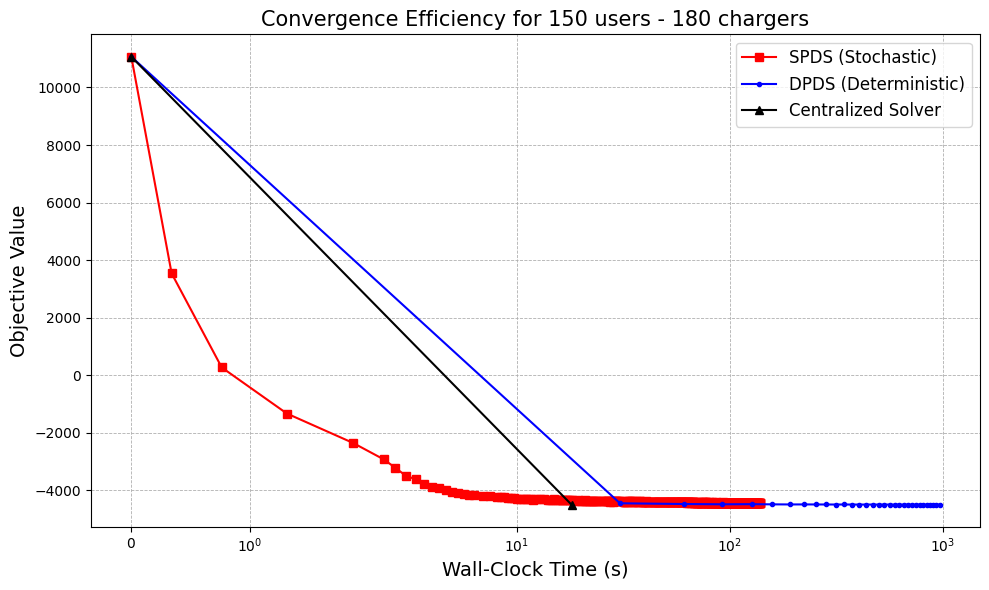

In [ ]:
file_path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_150u_180i.pkl"
file_path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_150u_180i.pkl"
file_path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_150u_180i.pkl"

with open(file_path_spds, "rb") as f1:
    spds = pickle.load(f1)
    spds_iter_time, spds_obj_hist = spds["time_log"], spds["objective"]
with open(file_path_dpds, "rb") as f1:
    dpds = pickle.load(f1)
    dpds_iter_time, dpds_obj_hist = dpds["time_log"], dpds["obj_hist"]
with open(file_path_solver, "rb") as f1:
    solver = pickle.load(f1)
    solver_obj, solver_time, solver_iterations = solver["objective"], solver["t_solver"], solver["iterations"]

# Visualization
efficiency_graph(spds_obj_hist, dpds_obj_hist, solver_obj,
                 spds_iter_time, dpds_iter_time, solver_time, solver_iterations, "150 users - 180 chargers")
# plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/efficiency_graph_150u_180i.png")
plt.show()

## 300 users 360 items

SPDS: 26831, 26831
DPDS: 4660, 4660
Solver: 2, 2


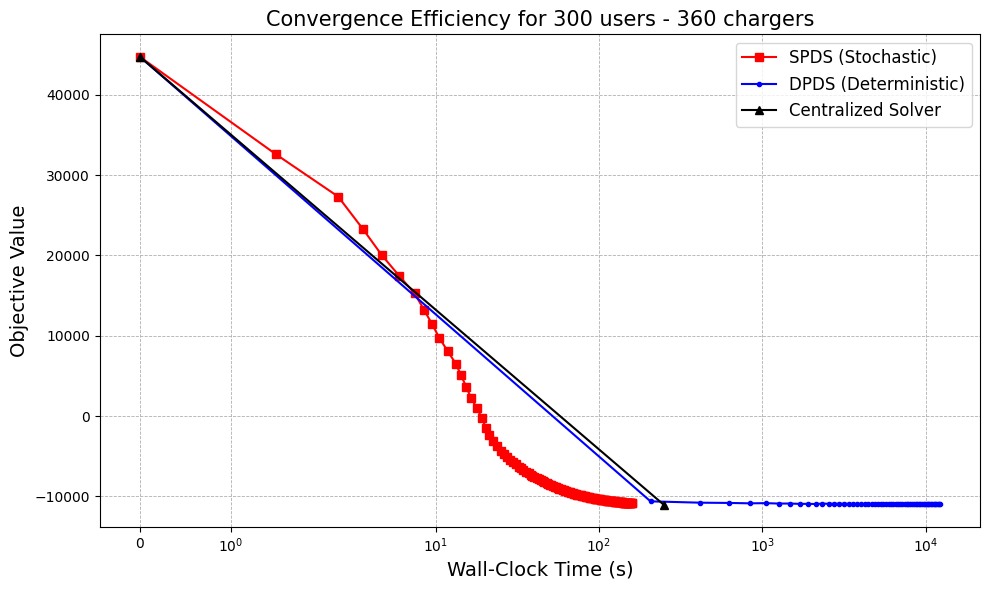

In [ ]:
file_path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_300u_360i.pkl"
file_path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_300u_360i.pkl"
file_path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_300u_360i.pkl"

with open(file_path_spds, "rb") as f:
    spds = pickle.load(f)
    spds_iter_time, spds_obj_hist = spds["time_log"], spds["objective"]
with open(file_path_dpds, "rb") as f:
    dpds = pickle.load(f)
    dpds_iter_time, dpds_obj_hist = dpds["time_log"], dpds["obj_hist"]
with open(file_path_solver, "rb") as f:
    solver = pickle.load(f)
    solver_obj, solver_time, solver_iterations = solver["objective"], solver["t_solver"], solver["iterations"]


# Visualization
efficiency_graph(spds_obj_hist, dpds_obj_hist, solver_obj,
                 spds_iter_time, dpds_iter_time, solver_time,
                 solver_iterations, "300 users - 360 chargers", 200, 80)
# plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/efficiency_graph_300u_360i.png")
plt.show()

## 400 users 480 items

SPDS: 38382, 38382
DPDS: 67, 67
Solver: 2, 2


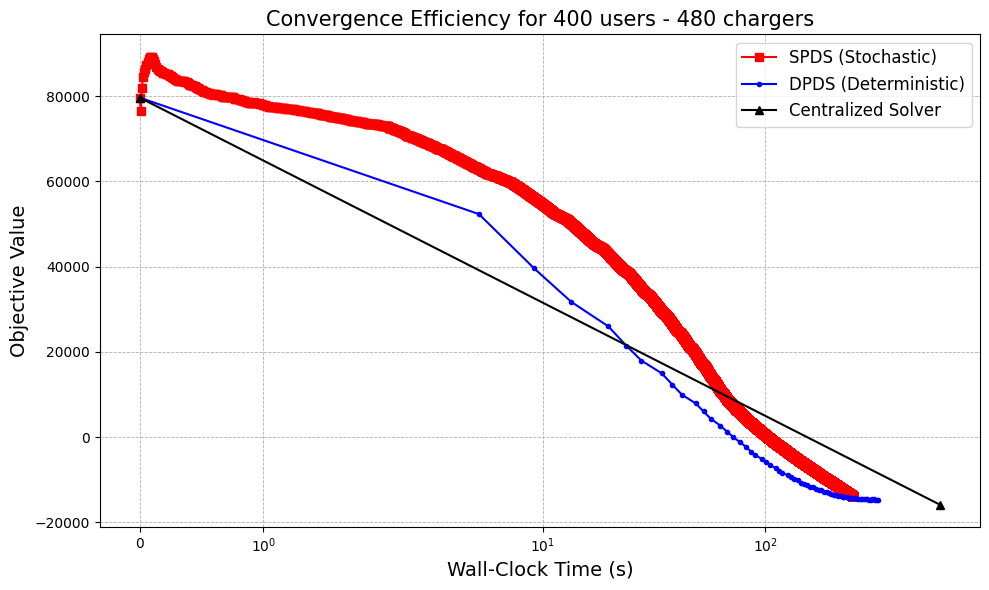

In [ ]:
file_path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_400u_480i.pkl"
file_path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_400u_480i.pkl"
file_path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_400u_480i.pkl"

with open(file_path_spds, "rb") as f:
    spds = pickle.load(f)
    spds_iter_time, spds_obj_hist = spds["time_log"], spds["objective"]
with open(file_path_dpds, "rb") as f:
    dpds = pickle.load(f)
    dpds_iter_time, dpds_obj_hist = dpds["time_log"], dpds["obj_hist"]
with open(file_path_solver, "rb") as f:
    solver = pickle.load(f)
    solver_obj, solver_time, solver_iterations = solver["objective"], solver["t_solver"], solver["iterations"]


# Visualization
efficiency_graph(spds_obj_hist, dpds_obj_hist, solver_obj,
                 spds_iter_time, dpds_iter_time, solver_time,
                 solver_iterations, "400 users - 480 chargers")
plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/efficiency_graph_400u_480i.png")
plt.show()

# 5. System Scalability (Not Run)
**Goal:** Demonstrate the algorithm's versatility across different utility functions and its superior scaling compared to centralized solvers.
* X-axis: Number of Users (N) (Log Scale).
* Y-axis: Time to Converge (s) (Log Scale).
* Description: Compares the computational scaling.
* Centralized Solver (Black Squares): Shows a steep, cubic scaling slope $O(N^3)$.
* Distributed SPDS (Blue Circles): Shows a much shallower, linear scaling slope $O(N)$, demonstrating superior scalability.

In [ ]:
def extract_users(key):
    """Extract number of users (integer before 'u') from keys like '50u_60i'."""
    return int(re.match(r"(\d+)u", key).group(1))

def scalability_graph(users_arr, solver_total_times, spds_total_times, dpds_total_times):
    """
    Parameters:
      - users_arr: Array of number of users.
      - solver_total_times: Array of total solver times.
      - spds_total_times: Array of total SPDS times.
    """

    plt.figure(figsize=(8, 6))
    plt.plot(users_arr, solver_total_times, '-*', markersize=8, linewidth=2, label="Centralized SCS Solver", color="black")
    plt.plot(users_arr, spds_total_times, '-s', markersize=8, linewidth=2, label="SPDS Algorithm", color="blue")
    plt.plot(users_arr, dpds_total_times, '-o', markersize=8, linewidth=2, label="DPDS Algorithm", color="red")
    plt.xticks(users_arr)
    plt.xlabel("Number of Agents (N)", fontsize=13)
    plt.ylabel("Wall-clock time (s)", fontsize=13)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(fontsize=12)
    plt.yscale("log")
    plt.tight_layout()

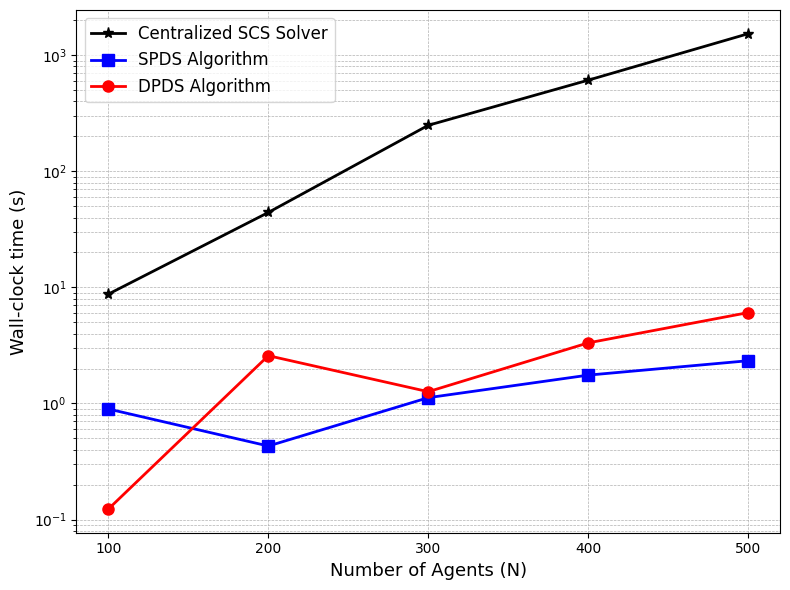

In [ ]:
path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result"
path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result"
path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result"
# Corrected keys list: each entry should be a single string representing a configuration
keys = ["100u_150i", "200u_240i", "300u_360i", "400u_480i", "500u_600i"]

# Initialize for both algorithms
# Use list comprehension with the existing 'extract_users' function
users_arr = [extract_users(k) for k in keys]
solver_total_times = []
dpds_total_times = []
spds_total_times = []

for k in keys:
    with open(f"{path_spds}/spds_results_{k}.pkl", "rb") as spds_f:
        spds = pickle.load(spds_f)
        spds_total_times.append(spds["time_log"][-1])

    with open(f"{path_dpds}/dpds_results_{k}.pkl", "rb") as dpds_f:
        dpds = pickle.load(dpds_f)
        dpds_total_times.append(dpds["time_log"][-1])

    with open(f"{path_solver}/cvxpy_results_{k}.pkl", "rb") as solver_f:
        solver = pickle.load(solver_f)
        solver_total_times.append(solver["t_solver"])

# VISUALIZATION
scalability_graph(users_arr, solver_total_times, spds_total_times, dpds_total_times)
plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/system_scalability.pdf", bbox_inches='tight')
plt.show()

# 6. Fairness Verification
**Goal:** Validate that the equilibrium allocation satisfies Proportionality and Envy-Freeness.

**Subplot a:** Proportionality Validation (Per-User)
* X-axis: User ID ($1 \dots 10$).
* Y-axis: Utility Value.
* *Success Criteria*: Every Blue Bar must extend above its corresponding Red Dash.

**Subplot b:** Pairwise Envy
* Type: Heatmap (10X10).
* Color: Diverging (Blue = Negative/Zero, Red = Positive).
* *Success Criteria*: Entire map is Blue/White. No Red.

In [ ]:
# --- ENVY FREENESS METRICS ---
def calculate_ces_utility(allocation_vec, valuations_vec, m=1):
    """
    Calculates CES utility for a single user based on the formula:
    U_i(x_i) = (sum_j (v_ij * x_ij)^m)^(1/m)

    Parameters:
    - allocation_vec: (k,) array of allocated goods for one user
    - valuations_vec: (k,) array of valuation weights for one user
    - m: exponent parameter. Can be an integer/float or 'inf'.
      If m='inf', calculates U_i(x_i) = max_j (v_ij * x_ij)

    Returns:
    - Scalar utility value for the user.
    """
    # Element-wise product: value derived from each item
    # shape: (k,)
    product = valuations_vec * allocation_vec

    if m == 'inf':
        # Limit case: Max over items
        return np.max(product, axis=1)
    else:
        # Standard CES form
        # We handle potential negative values by taking abs, though in this context x and v are usually non-negative.
        sum_pow = np.sum(np.power(product, m), axis=1)
        return np.power(sum_pow, 1/m)

def envy_freeness_ces(allocation, valuations, budgets, b_mat, A, p, q, m=1):
    """
    Checks Loose Envy Freeness condition using CES utility.
    User i envies User j if U_i(A_j) > U_i(A_i) + epsilon.

    Parameters:
    - allocation: (n, k) matrix of allocated goods
    - valuations: (n, k) matrix of linear valuations weights
    - m: exponent parameter for CES utility. Can be an integer/float or 'inf'.
    - epsilon: tolerance for envy check. U_i(A_j) > U_i(A_i) + epsilon.
    - return_relative_envy: If True, max_user_envy will be (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i).
                            Otherwise, it returns the absolute difference.

    Returns:
    - satisfaction_pct: Percentage of users who do not envy anyone (max_envy <= epsilon)
    - max_user_envy: List of max envy values for each user.
                     If return_relative_envy is True, Value = (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i)
                     Else, Value = (Max_j U_i(A_j) - U_i(A_i))
    """
    n = len(allocation)

    # Calculate utilities of each user for their own bundle
    u_own = calculate_ces_utility(allocation, valuations, m)
    user_envy_data = []

    for i in range(n):
        # Calculate utility of user i for EVERYONE's bundle
        # We tile user i's valuation to match the shape of allocation matrix
        val_i_matrix = np.tile(valuations[i], (n, 1))
        u_i_all = calculate_ces_utility(allocation, val_i_matrix, m)

        # Calculate difference: U_i(A_j) - U_i(A_i) (shape (n, 1) - scalar)
        # positive = envy, u_i_all = list of utitlity with allocation of different users and valuations i
        envy_values = u_i_all - u_own[i]
        # Check conditions: B_i = B_j and x_j^*, x_j is not feasible for buyer i under their budget constraint ((p + (A.T @ q[i])) @ allocation[j]) >= budgets[i])
        for j in range(n):
            if (budgets[i] != budgets[j]) or ((p + (A.T @ q[i])) @ allocation[j]) >= budgets[i]:
                envy_values[j] = 0

        # Result
        user_envy_data.append(envy_values)

    # Create Dataframe
    df = pd.DataFrame(user_envy_data, index=np.arange(1, n+1, 1), columns=np.arange(1, n+1, 1))
    df.index.name = 'User_I (Evaluatee)'
    df.columns.name = 'User_J (Evaluator)'

    return df

# ENVY HEATMAP
def create_heatmap(df, title):
  df = df.sort_index(ascending=False)
  plt.figure(figsize=(8, 6))
  if df.shape[0] > 20:
    plt.figure(figsize=(30, 20))
  obj = sns.heatmap(df, cmap='coolwarm', center=0,
              square=True, annot=True, fmt='.2f')
  plt.xlabel('EV User')
  plt.ylabel('EV User')

def proportional_fairness(alloc, spds_alloc, valuations, budgets):
    """
    Compare sum(B_i * u_i(x_i) / u_i(x_i*)) <= sum(B_i)
    where:
        B_i is the budget of user i
        u_i is the utility of user i
        x_i is the allocation of user i
        x_i is allocation x_i produced by other algorithm
        x_i* is allocation x_i produced by SPDS
    Returns:
        Compute sum_i B_i * u_i(x_i) / u_i(x_i^{SPDS})
    """
    n = alloc.shape[0]
    total = 0.0

    for i in range(n):
        util_method = alloc[i] @ valuations[i]
        util_spds = spds_alloc[i] @ valuations[i]

        total += budgets[i] * (util_method / util_spds)

    return total

## Constrained envy freeness

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# Import valuations
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(10, 24) + 0.5

# Load data
file_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_10u_24i.pkl"
solver_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_10u_24i.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)
with open(solver_path, "rb") as s1:
    df = pickle.load(s1)

# Parameters
p = data["data"]["p_new"]
q = data["data"]["q_new"]
budgets = data["data"]["budgets"]
b_mat = data["data"]["capacity_b"]
spds_alloc = data["alloc_final"]
solver_alloc = df["solver_alloc"]
A_matrix = data["data"]["A_matrix"]

✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)


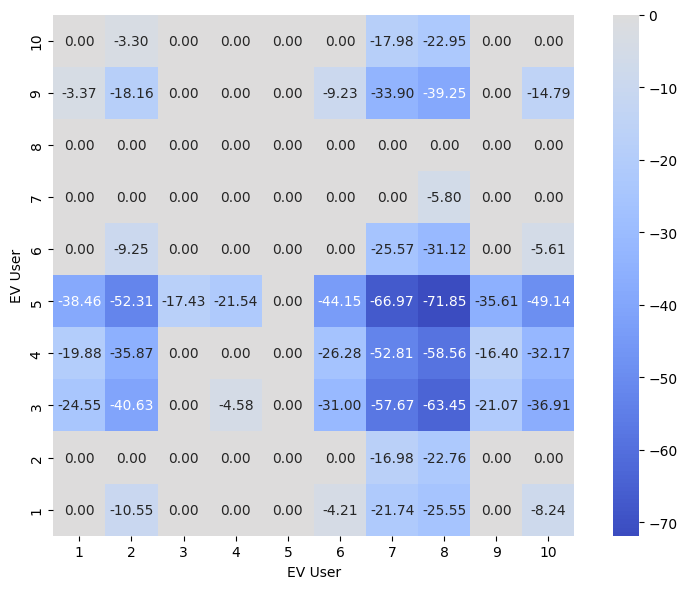

In [ ]:
# ENVY METRICS
envy_metrics_sgd = envy_freeness_ces(data["alloc_final"], valuations, budgets, b_mat, A_matrix, p, q, m=1)

# ENVY FAIRNESS SPDS
create_heatmap(envy_metrics_sgd, "SPDS (10 users - 24 chargers)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/envy_heatmap_spds.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

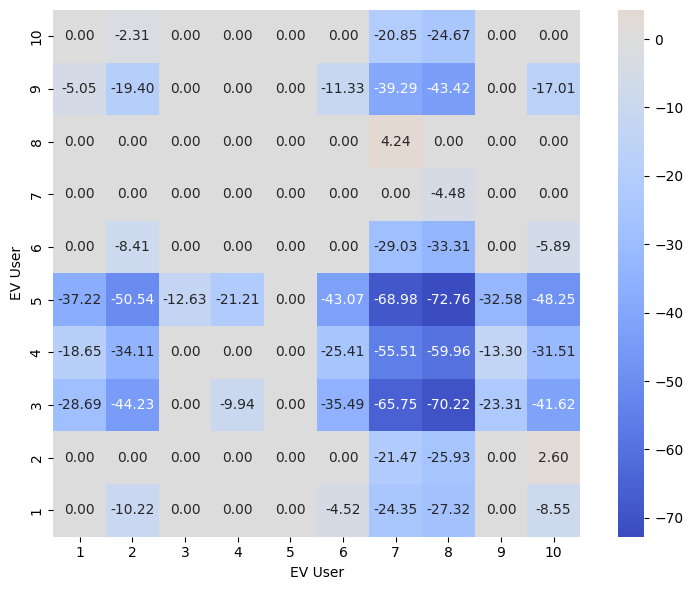

In [ ]:
envy_metrics_solver = envy_freeness_ces(df["solver_alloc"], valuations, budgets, b_mat, A_matrix, p, q, m=1)

# ENVY FAIRNESS SOLVER
create_heatmap(envy_metrics_solver, "Solver (10 users - 24 chargers)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/experiment_result/envy_heatmap_solver.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

##Proportional Fairness

In [ ]:
path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result"
path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result"
path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result"

keys = ["10u_24i", "50u_60i", "100u_150i", "150u_180i", "200u_240i", "300u_360i"]

results = []

for k in keys:
    # ---------- Load Valuation ----------
    FACTOR_DIR = f"/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_{k}"
    try:
        val_path = os.path.join(FACTOR_DIR, "valuation_matrix.npy")
        if os.path.exists(val_path):
            valuations = np.load(val_path)
        else:
            U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
            P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
            valuations = U @ P.T
    except:
        print("⚠️ Dùng dữ liệu ngẫu nhiên (Random Valuations)")
        valuations = np.random.rand(500, 600) + 0.1
    valuations /= 10

    # ---------- Load SPDS ----------
    with open(f"{path_spds}/spds_results_{k}.pkl", "rb") as f:
        spds = pickle.load(f)
        spds_alloc = spds["alloc_final"]
        budgets = spds["data"]["budgets"]

    # ---------- Load DPDS ----------
    with open(f"{path_dpds}/dpds_results_{k}.pkl", "rb") as f:
        dpds = pickle.load(f)
        dpds_alloc = dpds["alloc_final"]

    # ---------- Load Solver ----------
    with open(f"{path_solver}/cvxpy_results_{k}.pkl", "rb") as f:
        solver = pickle.load(f)
        solver_alloc = solver["solver_alloc"]

    # ---------- Compute sensitivity values ----------
    spds_val = proportional_fairness(
        spds_alloc, spds_alloc, valuations, budgets)

    dpds_val = proportional_fairness(
        dpds_alloc, spds_alloc, valuations, budgets)

    solver_val = proportional_fairness(
        solver_alloc, spds_alloc, valuations, budgets)

    results.append({
        "Test Case": k,
        "SPDS": spds_val,
        "DPDS": dpds_val,
        "Centralized Solver": solver_val})

In [ ]:
sensitivity_table = pd.DataFrame(results)
sensitivity_table.set_index("Test Case", inplace=True)
print(sensitivity_table)